# CNN LSTM Training 2

To detect actions in CCTVs</br>
CNN - for visual features</br>
LSTM - for temporal features



1.   Download visualize data with labels
2.   Preprocess data
3. Spliit into train and test
4. implement
5. construct the odel
6. compile and train the model
7. plot model loss and accuracy curves






## Import Requirements

In [ ]:
!pip install pafy youtube-dl moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Below code is used to make results repeatable (Reproducibility).
Every time you train a model,

Random numbers are used for:
*   Weight initialization
*   Data shuffling
*   Dropout

So results change every run. Therefore below code forces all randomness to behave the same every time.

In [ ]:
seed_constant = 27 #starting point for randomness
np.random.seed(seed_constant) #Randomness in NumPy -  random arrays, data sampling, shuffling
random.seed(seed_constant) #Randomness in Python’s built-in random module
tf.random.set_seed(seed_constant) #Randomness in TensorFlow / Keras - NN weight initialization, dropout, GPU

## Download and Visualize the data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# For our dataset
!unzip -q "/content/drive/MyDrive/Research/RVCNN.zip" -d "/content/RVCNN"

This reads the folder structure and files

In [ ]:
p = 'RVCNN/real dataset/Fighting/fighting_1.mp4'
cap = cv2.VideoCapture(p)
s, f = cap.read()
print("read ok?", s)
cap.release()

read ok? True


For visualization, 20 random categories from tha dataset and a randon video from each category and visualize first frame of them with associated labels written

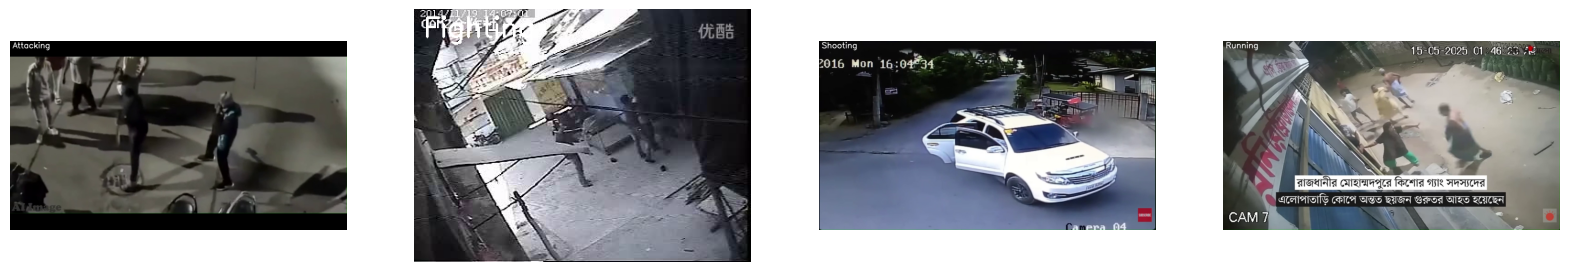

In [ ]:
#Create a matplotlib figure and specify the size of the figure
plt.figure(figsize = (20, 20))

# Root FOlder Path
ROOT = 'RVCNN/real dataset'

# Get the names of all classes/categories in UCF50
all_classes_names = os.listdir(ROOT)

# Get all 4 classes.
num_classes = range(len(all_classes_names))

#Iterating through all generated random values
for counter, random_index in enumerate(num_classes, 1):

  # Random class name using Random Index
  selected_class_name = all_classes_names[random_index]

  # Retrive the list of all the video files present in the randomly selected class directory
  video_files_names_list = os.listdir(f'{ROOT}/{selected_class_name}')

  #Pick One Random Video from That Class
  selected_video_file_name = random.choice(video_files_names_list)

  #Open the Video Using OpenCV
  video_reader = cv2.VideoCapture(f"{ROOT}/{selected_class_name}/{selected_video_file_name}")

  #Read the first frame of the video file
  # _, bgr_frame = video_reader.read()
  success, bgr_frame = video_reader.read()
  if not success:
      continue

  #Release the videoCapture object from memory.
  video_reader.release()

  #convert the frame from BGR to RGB format
  rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

  #Write the class name on the video frame
  cv2.putText(rgb_frame, selected_class_name, (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

  #Display the frame
  plt.subplot(5, 4, counter);plt.imshow(rgb_frame);plt.axis('off')


## Preprocess the data

Resize the image/frame into fixed size **(64x64)** pixels before going into the CNN.

Each video will be converted into 20 frames per sample

Out of all classes, your model will only learn these 4 actions.

In [ ]:
#Specify the height and width to which each video frame will be resized in our dataset
IMAGE_HEIGHT, IMAGE_WIDTH = 128, 128

#Specify the number of frames of a video that will be fed to the model as one sequence.
SEQUENCE_LENGTH = 16

#Specify the directory containing the UCF50 dataset.
DATASET_DIR = "RVCNN/real dataset"

#Specify the list containing the names of the classes used for training. Feel free to choose any set of classes
CLASSES_LIST = ["Fighting", "Running", "Attacking", "Shooting"]

**frames_extraction** function takes a video, picks 20 frames evenly from it, resizes them to 64×64, normalizes the pixel values, and returns them as a list for your CNN + LSTM model.

In [ ]:
def frames_extraction(video_path):

  #Declare a list to store video frames
  frames_list = []

  #Read the video file using videoCapture object
  video_reader = cv2.VideoCapture(video_path)

  #Get the total number of frames in the each video
  video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
  print(f"Total frames in video: {video_frames_count}")

  #Calculate the interval after which frames will be added to the list
  skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

  #Iterate through the Video Frames
  for frame_counter in range(SEQUENCE_LENGTH):

    #Set the current frame position of the video
    video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

    #Reading the frame from the video
    success, frame = video_reader.read()

    #Check if the Video frame is not successfully read then break the loop
    if not success:
      print(f"Failed to read frame at position {frame_counter * skip_frames_window}")
      break

    #Resize the frame to fixed height and width
    resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

    #Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
    normalized_frame = resized_frame / 255

    #Append the normalized frame into frames list
    frames_list.append(normalized_frame)

  # Release the VideoCapture Object.
  video_reader.release()

  # Print total frames
  print(f"Total frames extracted: {len(frames_list)}\n")

  # Return the frames list
  return frames_list


**Visualize Frames after Resizing and Normalizing**

**Check Number of Processed Videos**

**create_dataset** function or Dataset Creation function goes through all your class folders,
reads every video, extracts 20 frames from each video, assigns a label, and finally returns everything as NumPy arrays for model training.

In [ ]:
def create_dataset():

  # Declared Empty Lists to store the features, labels and video file path values.
  features = []
  labels = []
  video_files_paths = []

  total_videos = 0
  accepted_videos = 0
  skipped_videos = 0
  class_counts = {class_name: 0 for class_name in CLASSES_LIST}

  #Iterating through all the classes mentioned in the classes list
  for class_index, class_name in enumerate(CLASSES_LIST):

    # Display the name of the class whose data is being extracted.
    print(f'Extracting Data of Class: {class_name}')

    # Get the list of video files present in the specific class name directory.
    files_list = os.listdir(os.path.join(DATASET_DIR, class_name))

    # Iterate through all the files present in the files list
    for file_name in files_list:

      # Add to total videos
      total_videos += 1

      # Get the complete video path.
      video_file_path = os.path.join(DATASET_DIR, class_name, file_name)

      # Extract the frames of the video file
      frames = frames_extraction(video_file_path)

      # Check if the extracted frames are equal to the SEQUENCE_LENGTH specified above
      # So ignore the videos having frames less than the SEQUENCE_LENGTH
      if len(frames) == SEQUENCE_LENGTH:

        accepted_videos += 1
        class_counts[class_name] += 1

        # Append the data to their respective lists
        features.append(frames)
        labels.append(class_index)
        video_files_paths.append(video_file_path)

      else:
        skipped_videos += 1

  # Converting the list to numpy arrays
  features = np.asarray(features)
  labels = np.array(labels)

  # Print summary
  print("\n================ VIDEO SUMMARY ================")
  print(f"Total videos found: {total_videos}")
  print(f"Accepted videos   : {accepted_videos}")
  print(f"Skipped videos    : {skipped_videos}")
  print("================================================")

  print("\nAccepted videos per class:")
  for cls, count in class_counts.items():
      print(f"{cls}: {count}")

  # Return the frames, class index and video file path
  return features, labels, video_files_paths

Utilizing the function create_dataset() created above to extract the data of the selected classes and create the required dataset.

In [ ]:
# Create the dataset
features, labels, video_files_paths = create_dataset()

Extracting Data of Class: Fighting
Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 158
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 171
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 109
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Total frames extracted: 16

Total frames in video: 150
Tot

Final Checklist Checker

Dataset folder exists: True RVCNN/real dataset
Classes on disk: ['Attacking', 'Fighting', 'Running', 'Shooting']
Requested CLASSES_LIST: ['Fighting', 'Running', 'Attacking', 'Shooting']

Raw video counts per class:
  Fighting: 67
  Running: 57
  Attacking: 65
  Shooting: 66
Total raw videos: 255

Preprocessed arrays:
  features.shape: (255, 16, 128, 128, 3)
  labels.shape  : (255,)

Dimension checks:
  Sequence length OK: True (expected 16, got 16)
  Frame H OK: True (expected 128, got 128)
  Frame W OK: True (expected 128, got 128)

Pixel range (checked on random samples): min = 0.0 max = 1.0
features.dtype: float64

Label distribution (index:count):
  0 (Fighting): 67
  1 (Running): 57
  2 (Attacking): 65
  3 (Shooting): 66

Accepted (kept) videos: 255
Skipped videos (short/unreadable): 0

Memory estimate for features array: 1530.00 MB

Sample video 168, label 2 (Attacking), path: RVCNN/real dataset/Attacking/attacking_16.avi


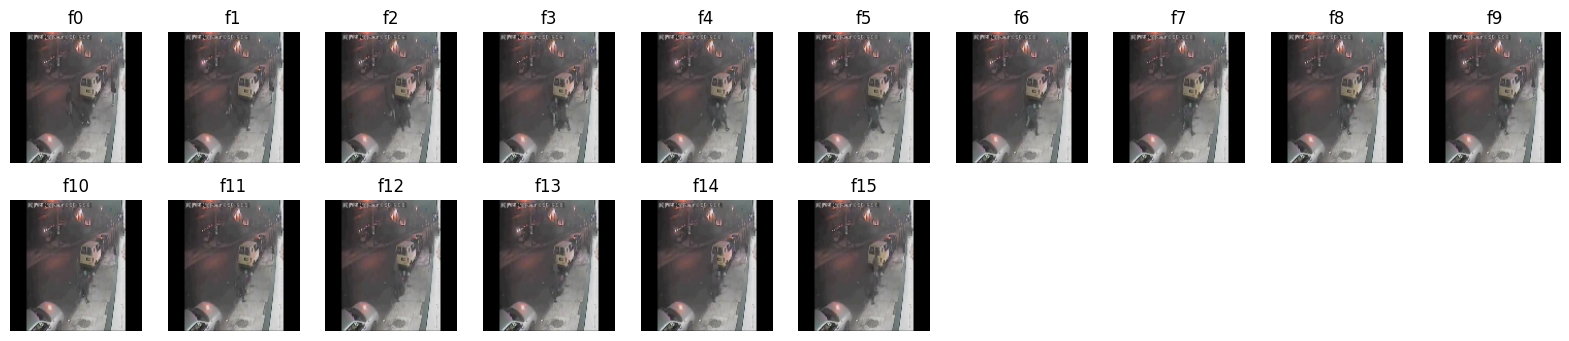


Checklist complete.


In [ ]:
import os
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def dataset_checklist(run_create_if_missing=True, show_sample_frames=0):
    """
    Run a checklist on dataset and preprocessed arrays.
    Assumes these names exist in the notebook scope:
      - DATASET_DIR, CLASSES_LIST, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH
      - frames_extraction(), create_dataset() available
      - optionally: features, labels, video_files_paths already created
    Returns: dict with results
    """
    info = {}
    # 1) Basic dataset folder sanity
    info['dataset_dir_exists'] = os.path.isdir(DATASET_DIR)
    print("Dataset folder exists:", info['dataset_dir_exists'], DATASET_DIR)
    if not info['dataset_dir_exists']:
        return info

    # list class folders on disk
    disk_classes = [d for d in sorted(os.listdir(DATASET_DIR)) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    info['disk_classes'] = disk_classes
    print("Classes on disk:", disk_classes)
    print("Requested CLASSES_LIST:", CLASSES_LIST)

    # 2) Per-class raw video counts
    per_class_raw = {}
    total_raw = 0
    for cls in CLASSES_LIST:
        cls_dir = os.path.join(DATASET_DIR, cls)
        if os.path.isdir(cls_dir):
            files = [f for f in os.listdir(cls_dir) if not f.startswith('.')]
            per_class_raw[cls] = len(files)
            total_raw += len(files)
        else:
            per_class_raw[cls] = 0
    info['per_class_raw_counts'] = per_class_raw
    info['total_raw_videos'] = total_raw
    print("\nRaw video counts per class:")
    for k,v in per_class_raw.items():
        print(f"  {k}: {v}")
    print("Total raw videos:", total_raw)

    # 3) Ensure features/labels/video_files_paths exist — optionally build them
    global features, labels, video_files_paths
    arrays_prepared = ('features' in globals() and 'labels' in globals() and 'video_files_paths' in globals())
    info['arrays_prepared_before'] = arrays_prepared
    if not arrays_prepared and run_create_if_missing:
        print("\nfeatures/labels missing — running create_dataset() to build them (this may take time)...")
        features, labels, video_files_paths = create_dataset()
        arrays_prepared = True

    if not arrays_prepared:
        print("\nNo features/labels available. Stop here.")
        return info

    # 4) Basic arrays checks
    info['features_shape'] = features.shape
    info['labels_shape'] = labels.shape
    info['num_samples'] = features.shape[0] if features is not None else 0
    print("\nPreprocessed arrays:")
    print("  features.shape:", features.shape)
    print("  labels.shape  :", labels.shape)

    # 5) Check sequence length dimension and frame size
    ok_seq = (features.shape[1] == SEQUENCE_LENGTH)
    ok_h = (features.shape[2] == IMAGE_HEIGHT)
    ok_w = (features.shape[3] == IMAGE_WIDTH)
    info['ok_sequence_length'] = ok_seq
    info['ok_frame_height'] = ok_h
    info['ok_frame_width'] = ok_w
    print("\nDimension checks:")
    print("  Sequence length OK:", ok_seq, f"(expected {SEQUENCE_LENGTH}, got {features.shape[1]})")
    print("  Frame H OK:", ok_h, f"(expected {IMAGE_HEIGHT}, got {features.shape[2]})")
    print("  Frame W OK:", ok_w, f"(expected {IMAGE_WIDTH}, got {features.shape[3]})")

    # 6) dtype and pixel range checks (sample a few to save time)
    info['features_dtype'] = features.dtype
    sample_idxs = np.random.choice(max(1, features.shape[0]), min(20, features.shape[0]), replace=False)
    mins = []
    maxs = []
    for i in sample_idxs:
        mins.append(float(features[i].min()))
        maxs.append(float(features[i].max()))
    info['pixel_min'] = float(np.min(mins))
    info['pixel_max'] = float(np.max(maxs))
    print("\nPixel range (checked on random samples): min =", info['pixel_min'], "max =", info['pixel_max'])
    print("features.dtype:", info['features_dtype'])

    # 7) Class balance & label validity
    label_counter = Counter(labels.tolist())
    info['label_counts'] = dict(label_counter)
    print("\nLabel distribution (index:count):")
    for idx, cnt in label_counter.items():
        name = CLASSES_LIST[idx] if idx < len(CLASSES_LIST) else "UNKNOWN"
        print(f"  {idx} ({name}): {cnt}")

    # 8) Compare accepted vs raw videos and show skipped
    accepted = len(video_files_paths)
    info['accepted_videos'] = accepted
    info['skipped_videos'] = total_raw - accepted
    print("\nAccepted (kept) videos:", accepted)
    print("Skipped videos (short/unreadable):", info['skipped_videos'])

    # 9) Duplicate checks
    dup_paths = [p for p,c in Counter(video_files_paths).items() if c>1]
    info['duplicate_video_paths'] = dup_paths
    if dup_paths:
        print("\nWarning: duplicate video paths found (same file used multiple times):", dup_paths)

    # 10) Memory estimate
    bytes_used = features.nbytes
    info['features_bytes'] = int(bytes_used)
    print("\nMemory estimate for features array: {:.2f} MB".format(bytes_used/1024/1024))

    # 11) Quick visual sample if requested
    if show_sample_frames and features.shape[0] > 0:
        nshow = min(show_sample_frames, features.shape[0])
        picks = np.random.choice(features.shape[0], nshow, replace=False)
        for i, pidx in enumerate(picks, 1):
            frames = features[pidx]  # shape (T,H,W,3)
            lbl = labels[pidx]
            print(f"\nSample video {pidx}, label {lbl} ({CLASSES_LIST[lbl]}), path: {video_files_paths[pidx]}")
            T = frames.shape[0]
            cols = min(10, T)
            rows = int(np.ceil(T/cols))
            plt.figure(figsize=(cols*2, rows*2))
            for t in range(T):
                f = (frames[t] * 255).astype('uint8')
                f_rgb = f[..., ::-1]  # BGR->RGB if necessary (depends on how you stored)
                plt.subplot(rows, cols, t+1)
                plt.imshow(f_rgb)
                plt.axis('off')
                plt.title(f"f{t}")
            plt.show()

    print("\nChecklist complete.")
    return info

# Example: run the checks, and visually show 1 sample video's frames
results = dataset_checklist(run_create_if_missing=True, show_sample_frames=1)


Final Frame Checker - Shows preprocessed frames (resized + normalized) for random videos.


Showing preprocessed frames for video:
RVCNN/real dataset/Shooting/shooting_158.mp4
Label index: 3


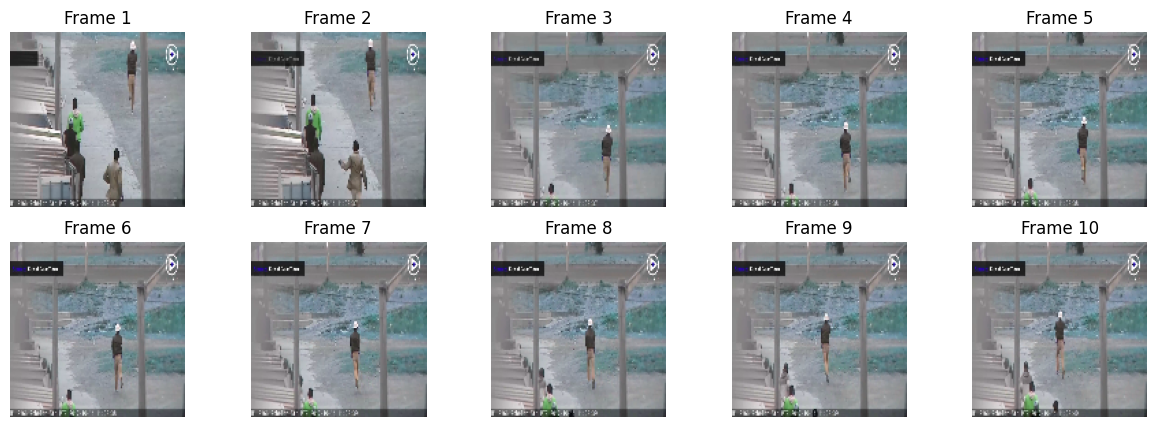


Showing preprocessed frames for video:
RVCNN/real dataset/Attacking/attacking_35.avi
Label index: 2


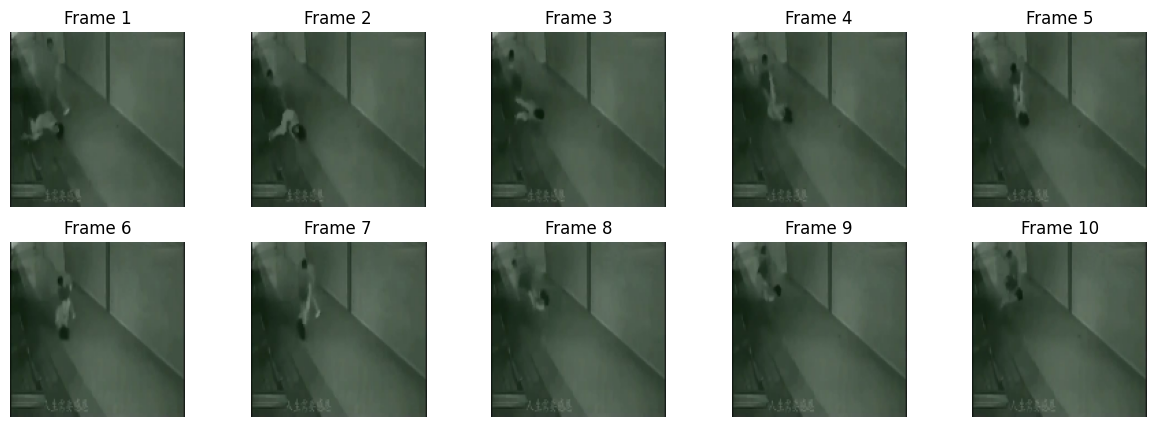


Showing preprocessed frames for video:
RVCNN/real dataset/Running/running_110.mp4
Label index: 1


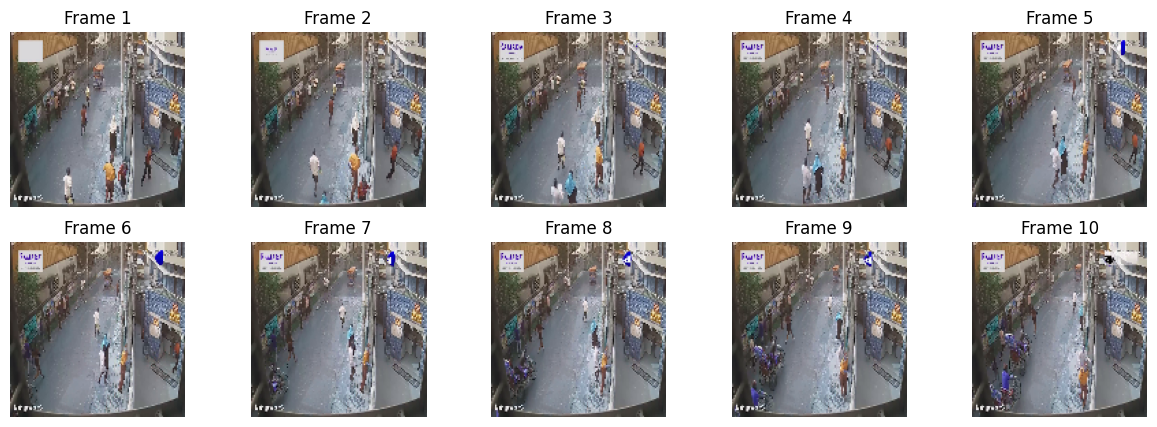

In [ ]:
import matplotlib.pyplot as plt
import random

def show_preprocessed_frames(features, labels, video_files_paths, num_videos=3):

  # Pick random video indices
  random_indices = random.sample(range(len(features)), num_videos)

  for vid in random_indices:

    frames = features[vid]      # shape: (SEQUENCE_LENGTH, H, W, 3)
    label = labels[vid]
    path  = video_files_paths[vid]

    print(f"\nShowing preprocessed frames for video:\n{path}")
    print(f"Label index: {label}")

    plt.figure(figsize=(15, 5))

    # Show first 10 frames only (for neat layout)
    for i in range(min(10, len(frames))):
        frame = frames[i]

        # Because frames are normalized, multiply by 255 to display
        frame_display = (frame * 255).astype("uint8")

        plt.subplot(2, 5, i+1)
        plt.imshow(frame_display)
        plt.title(f"Frame {i+1}")
        plt.axis('off')

    plt.show()

# Run it
show_preprocessed_frames(features, labels, video_files_paths, num_videos=3)


Convert labels (class indexes) into one hot encoded vectors

In [ ]:
# Using keras's to_categorical method to convert lebels into one-hot-encoding vectors
one_hot_encoded_labels = to_categorical(labels)

## Spliit the Data into Train and Test set

Until here required features (A numpy array containing extracted frames of the videos) and one_hot_encoded_labels (also a numpy array containing all class labels in one hot encoded format). Therefore shuffle the dataset and split

In [ ]:
# Split the Data into Train (75%) and Test Set (25%)
features_train, features_test, labels_train, labels_test = train_test_split(features,
                                                                            one_hot_encoded_labels,
                                                                            test_size = 0.25,
                                                                            shuffle =True,
                                                                            random_state = seed_constant)

plot_metric function - to create graphs

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
  '''
  This function will plot the metrices passes to it in a graph.
  Args:
    model_training_history: A history object containing a record of training and validation
                            loss values and metrices values at successive epochs
    metric_name_1: The name of the first metric that needs to be plotted in the graph.
    metric_name_2: The name of the second etric that needs to be plotted in the graph.
  '''

  # Get metric values using metric names as identifiers.
  metric_value_1 = model_training_history.history[metric_name_1]
  metric_value_2 = model_training_history.history[metric_name_2]

  # Construct a range object which will be used as x-axis (horixontal plane) of the graph
  epochs = range(len(metric_value_1))

  # PLot the graph
  plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
  plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

  # Add titel to the plot
  plt.title(str(plot_name))

  # add legend to the plot
  plt.legend()

## Implement the LRCN approach

Construct the model LRCN with **create_LRCN_model()** function

In [ ]:
def create_LRCN_model():
  '''
  This function will construct the required LRCN model.
  Returns:
    model: It is the required constructed LRCN model.
  '''

  # Sequential model for model construction
  model  = Sequential()

  #Define the model Architecture
  ######################################################################

  model.add(TimeDistributed(Conv2D(16, (3, 3), padding = 'same', activation = 'relu'),
                            input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

  model.add(TimeDistributed(MaxPooling2D((4, 4))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(32, (3, 3), padding = 'same', activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((4, 4))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(64, (3, 3), padding = 'same', activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((2, 2))))
  model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Conv2D(64, (3, 3), padding = 'same', activation = 'relu')))
  model.add(TimeDistributed(MaxPooling2D((2, 2))))
  # model.add(TimeDistributed(Dropout(0.25)))

  model.add(TimeDistributed(Flatten()))

  model.add(LSTM(32))

  model.add(Dense(len(CLASSES_LIST), activation = 'softmax'))

  ###############################################################################

  # Display the models summary.
  model.summary()

  # Return the constructed LRCN model.
  return model

Construct the required LRCN model.

In [ ]:
# Construct the required LRCN model
LRCN_model = create_LRCN_model()

#Display the sucess message
print("Model Created Successfully!")

  super().__init__(**kwargs)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 128, 128,   │           448 │
│ (TimeDistributed)               │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 32, 32, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 16, 8, 8, 64)   │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 16, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 16, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 16, 4, 4, 64)   │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 16, 2, 2, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 16, 256)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,636 (381.39 KB)

 Trainable params: 97,636 (381.39 KB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!


Check models strcuture

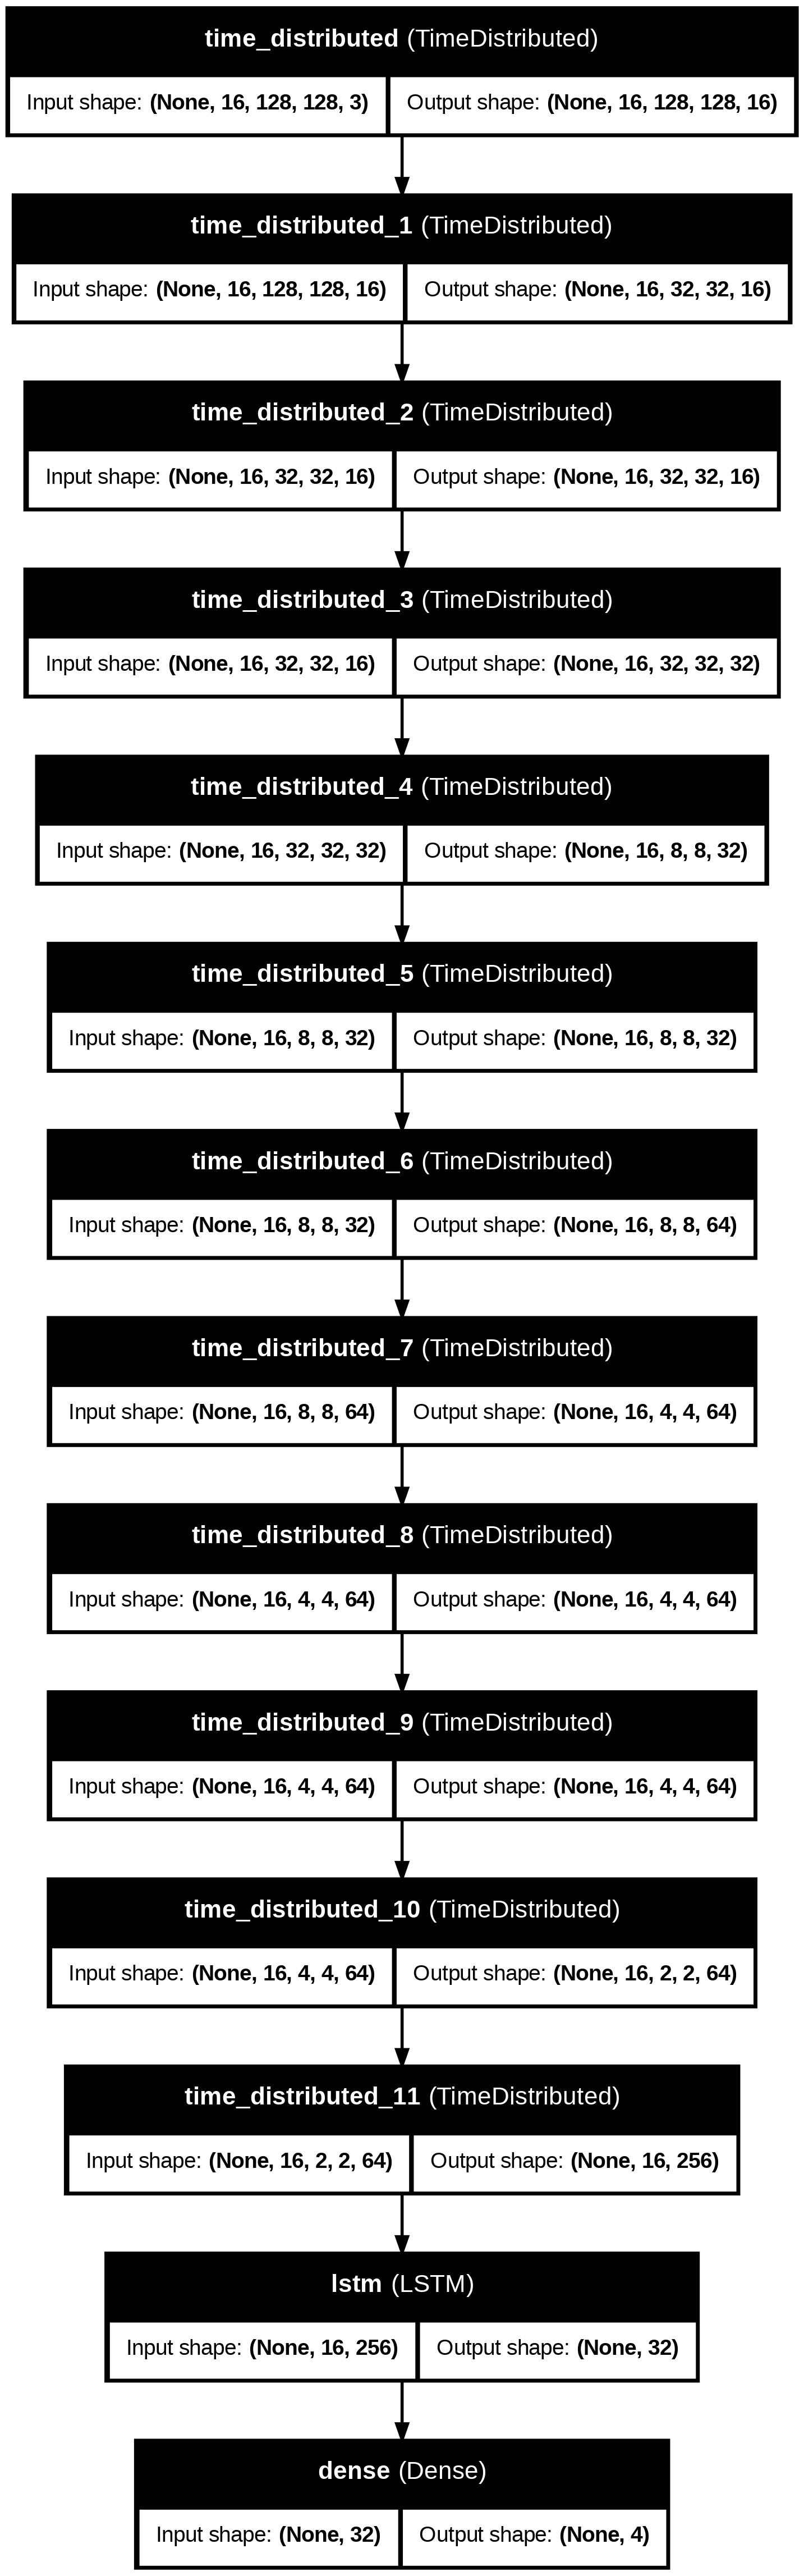

In [ ]:
plot_model(LRCN_model, to_file = 'LRCN_model_strcuture_plot.png', show_shapes = True, show_layer_names = True)

## Compile and Train LRCN Model

In [ ]:
# Create an Instance fo Early Stopping Callback
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrices to the model.
LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model
LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 70, batch_size = 4,
                                             shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])

Epoch 1/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.3226 - loss: 1.4252 - val_accuracy: 0.3590 - val_loss: 1.3838
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3665 - loss: 1.3780 - val_accuracy: 0.2051 - val_loss: 1.3883
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.3393 - loss: 1.3652 - val_accuracy: 0.2051 - val_loss: 1.3834
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.3617 - loss: 1.3404 - val_accuracy: 0.3846 - val_loss: 1.3750
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.3809 - loss: 1.2915 - val_accuracy: 0.4615 - val_loss: 1.3807
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.4448 - loss: 1.2326 - val_accuracy: 0.5641 - val_loss: 1.3499
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5063 - loss: 1.1407 - val_accuracy: 0.5128 - val_loss: 1.3606
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.5744 - loss: 1.0401 - val_accuracy: 0.4359 - val_loss

## Evaluate the LRCN model

In [ ]:
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6146 - loss: 1.0593 


## Save the LRCN model

In [ ]:
# Get the loss and accuracy from model_evaluation_history
model_evaluation_loss, model_evaluation_acccuracy = model_evaluation_history

# Define the string date format
# Get the current Date and Time in a DateTime object
# Convert the DateTIme object to string according to the style mentioned in date_time_format string
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models
model_file_name = f'LRCN_model__Date_Time_{current_date_time_string}__Loss_{model_evaluation_loss}__Accuracy_{model_evaluation_acccuracy}.h5'

# Save the model
LRCN_model.save(model_file_name)

Visualize the training and validation loss metrices. Plot models loss and Accuracy metrices


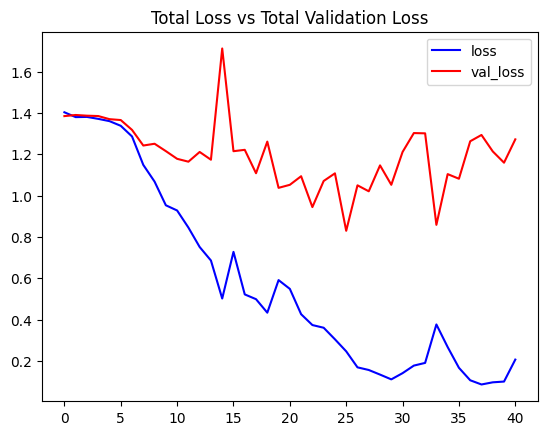

In [ ]:
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

Visualize the training and Validation accuracy metrices

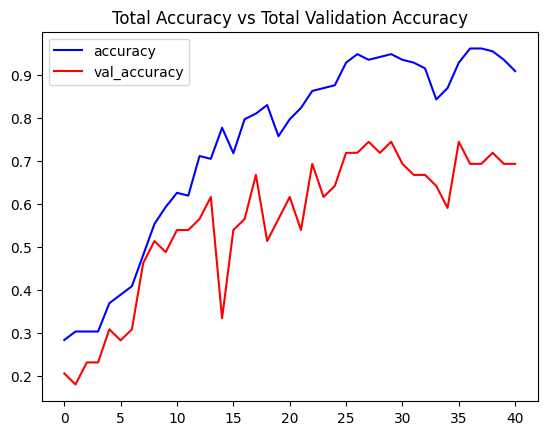

In [ ]:
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

# Test the Best Performing Model on Youtube Videos

Function to Download Youtube Videos

In [ ]:
def download_youtube_videos(youtube_video_url, output_directory):
  '''
  This function downloades youtube videos which URL is passes to it as an argument.
  Args:
    youtube_video_url: URL of the video that is required to be donwloaded.
    output_directory: The directory path to which the video needds to be stored after downloading
  Returns:
    title of the odwnloaded youtube video.
  '''

  # Create a video object which contains useful information about the video.
  video = pafy.new(youtube_video_url)

  # Retrive the title of the video
  title = video.title

  # Get the best awailable quality object for the video
  video_best = video.getbest()

  # Construct the output file path.
  output_file_path = f'{output_directory}/{title}.mp4'

  # Download the youtube video at the best available quality and store it to the constructed path
  video_best.download(filepath = output_file_path, quiet = True)

  # Return the video title
  return titlw

Download a Test video from Youtube using the above methos

In [ ]:
# Make the Output directory if it does not exist
test_videos_directory = 'test_videos'
os.makedirs(test_videos_directory, exist_ok = True)

# Download a youtube video
video_title = download_youtube_videos('', test_videos_directory)

# Get the Youtube Video's path we just downloaded
input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

Or else, import the downloaded video from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp '/content/drive/MyDrive/Test Video.mp4' 'test_videos/Test Video.mp4'

# Make the Output directory if it does not exist
test_videos_directory = 'test_videos'
video_title = 'Test Video'
os.makedirs(test_videos_directory, exist_ok = True)

# Video's input file path
input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Perform Action recognition on downloaded youtube videos.

Change this code inorder to raise alert alarms after whihc number of frames or seconds. Becasue expensive to predict after every frame. Change the design for activity monitering system

In [ ]:
def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH):
  '''
  This function will perform action recognition on a video using the LRCN model.
  Args:
    video_file_path: video stored in disk which the action recognition is to be performed
    output_file_path: The path where the output video with the predicted action being performed overlayed will be stored
    SEQUENCE_LENGTH: fixed number of frames of a videocan be passes to the model as one sequence.
  '''

  #Initialize the VideoCapture object to read from the video file
  video_reader = cv2.VideoCapture(video_file_path)

  # Get the width and hegiht of the video
  original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
  original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

  # Initialize the videowriter object to store the output video in the disk
  video_writer = cv2.VideoWriter(output_file_path, cv2VideoWriter_fourcc('M', 'P', '4', 'V'),
                                 video_reader.get(cv2.CAP_PROP_FPS), (original_video_width, original_video_height))

  # Declare a queue to store video frames
  frames_queue = deque(maxlen = SEQUENCE_LENGTH)

  # Initialize a variable to store the predicted action being performed in the video
  predicted_class_name = ''

  # Iterare until the video is accessed successfully
  while video_reader.isOpened():

    # Read the frame
    ok, frame = video_reader.read()

    # Check if frame is not read properly then break the loop
    if not ok:
      break

    # Resize the frame to fixed dimensions
    resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

    # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
    normalized_frame = resized_frame / 255

    # Appending the pre=processed frame into the frames list
    frames_queue.append(normalized_frame)

    # Check if the number of frames in the queue are equal to the fixed sequence length.
    if len(frames_queue) == SEQUENCE_LENGTH:

      # Pass the normalized frames to the model and get the predicted probabailities
      predicted_labels_probabilities = LRCN_model.predict(np.expand_dims(frames_queue, axis = 0))[0]

      # Get the index of class with the highest probability
      predicted_label = np.argmax(predicted_labels_probabilities)

      # Get the class name using the retrived index
      predicted_class_name = CLASSES_LIST[predicted_label]

    # Write predicted class name on top of the frame
    cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Write the frame into the disk using the VideoWriter Object.
    video_writer.write(frame)

  # Release the VideoCapture and Videowriter objects
  video_reader.release()
  video_writer.release()


Perform action recognition on the test video

In [ ]:
# Construct the output video patht
output_video_file_path = f'{test_videos_directory}/{video_title}-Output-SeqLen{SEQUENCE_LENGTH}.mp4'

# Perform Action Recognition on the Test Video
predict_on_video(input_video_file_path, output_video_file_path, SEQUENCE_LENGTH)

# Display the output video
VideoFileClip(output_video_file_path, audio = False, target_resolution=(300, None)).ipython_display()